<a href="https://www.kaggle.com/code/sonawanelalitsunil/myntra-sales-dataset-ml?scriptVersionId=260772525" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/myntra-sales-dataset/myntra_dataset_ByScraping.csv


## Title:
📊 Myntra Sales Dataset

## Description:
The Myntra Sales Dataset provides detailed insights into customer transactions, product categories, pricing, and sales performance on the Myntra platform. It captures essential information such as product details, order transactions, customer demographics, payment methods, and ratings. This dataset can be used to analyze consumer purchasing behavior, identify top-performing products, track seasonal sales trends, evaluate the impact of discounts, and build predictive models for sales forecasting. It is valuable for data analysis, machine learning applications, and business strategy development in the e-commerce domain.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/myntra-sales-dataset/myntra_dataset_ByScraping.csv")

In [3]:
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings
0,WROGN,Men Loose Fit Cotton Jeans,1374.0,2499.0,0.45,4.2,57.0
1,Flying Machine,Men Slim Fit Jeans,1829.0,2999.0,0.39,4.6,5.0
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0


In [4]:
df.tail()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings
52115,Pepe Jeans,Men Slim Fit Jeans,759.0,1899.0,0.6,4.0,63.0
52116,HERE&NOW,Men Slim Fit Jeans,759.0,1899.0,0.6,4.0,63.0
52117,Pepe Jeans,Men Slim Fit Jeans,759.0,1899.0,0.6,4.0,63.0
52118,Celio,Men Straight Fit Jeans,759.0,1899.0,0.6,4.0,63.0
52119,Pepe Jeans,Men Slim Fit Jeans,759.0,1899.0,0.6,4.0,63.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52120 entries, 0 to 52119
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand_name         52120 non-null  object 
 1   pants_description  52120 non-null  object 
 2   price              52120 non-null  float64
 3   MRP                52120 non-null  float64
 4   discount_percent   52120 non-null  float64
 5   ratings            52120 non-null  float64
 6   number_of_ratings  52120 non-null  float64
dtypes: float64(5), object(2)
memory usage: 2.8+ MB


In [6]:
df.describe()

,price,MRP,discount_percent,ratings,number_of_ratings
count,52120.000000,52120.000000,52120.000000,52120.000000,52120.000000
mean,1594.515445,3180.398438,1.648256,3.997794,91.568937
std,1495.972325,2201.883218,4.687529,0.420404,433.918513
min,337.000000,499.000000,0.020000,1.000000,5.000000
25%,989.000000,2499.000000,0.400000,3.800000,16.000000
50%,1439.000000,2999.000000,0.500000,4.000000,35.000000
75%,1829.000000,3499.000000,0.630000,4.200000,74.000000
max,54000.000000,72000.000000,64.000000,5.000000,30700.000000


In [7]:
df.dtypes

brand_name            object
pants_description     object
price                float64
MRP                  float64
discount_percent     float64
ratings              float64
number_of_ratings    float64
dtype: object

In [8]:
df.shape

(52120, 7)

In [9]:
df.isnull().sum()

brand_name           0
pants_description    0
price                0
MRP                  0
discount_percent     0
ratings              0
number_of_ratings    0
dtype: int64

In [10]:
df.duplicated().sum()

17047

In [11]:
df.columns

Index(['brand_name', 'pants_description', 'price', 'MRP', 'discount_percent',
       'ratings', 'number_of_ratings'],
      dtype='object')

## Data visulizations|

<Figure size 1200x600 with 0 Axes>

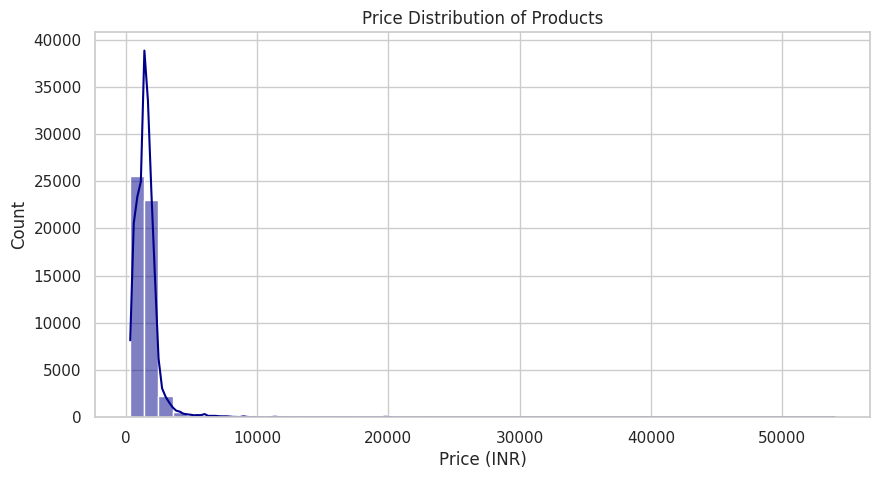

In [12]:
sns.set(style="whitegrid", palette="muted")
plt.figure(figsize=(12, 6))

# 1. Distribution of Prices
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color="darkblue")
plt.title("Price Distribution of Products")
plt.xlabel("Price (INR)")
plt.ylabel("Count")
plt.show()

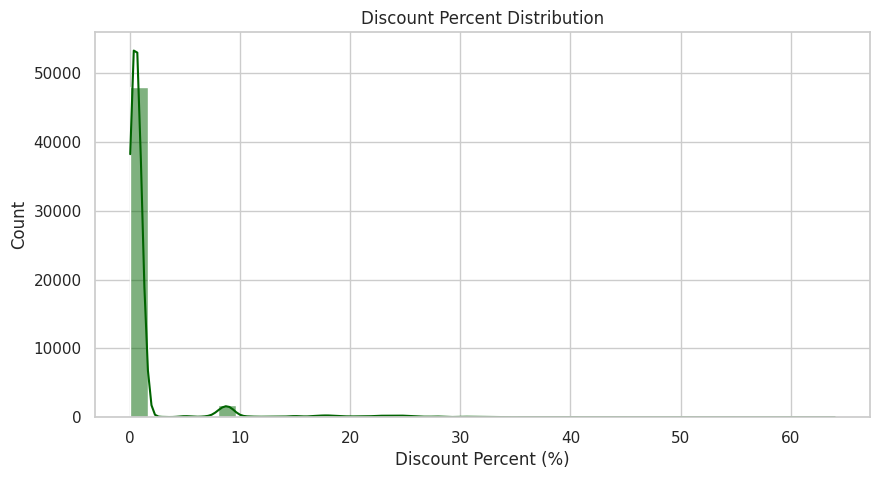

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['discount_percent'], bins=40, kde=True, color="darkgreen")
plt.title("Discount Percent Distribution")
plt.xlabel("Discount Percent (%)")
plt.ylabel("Count")
plt.show()


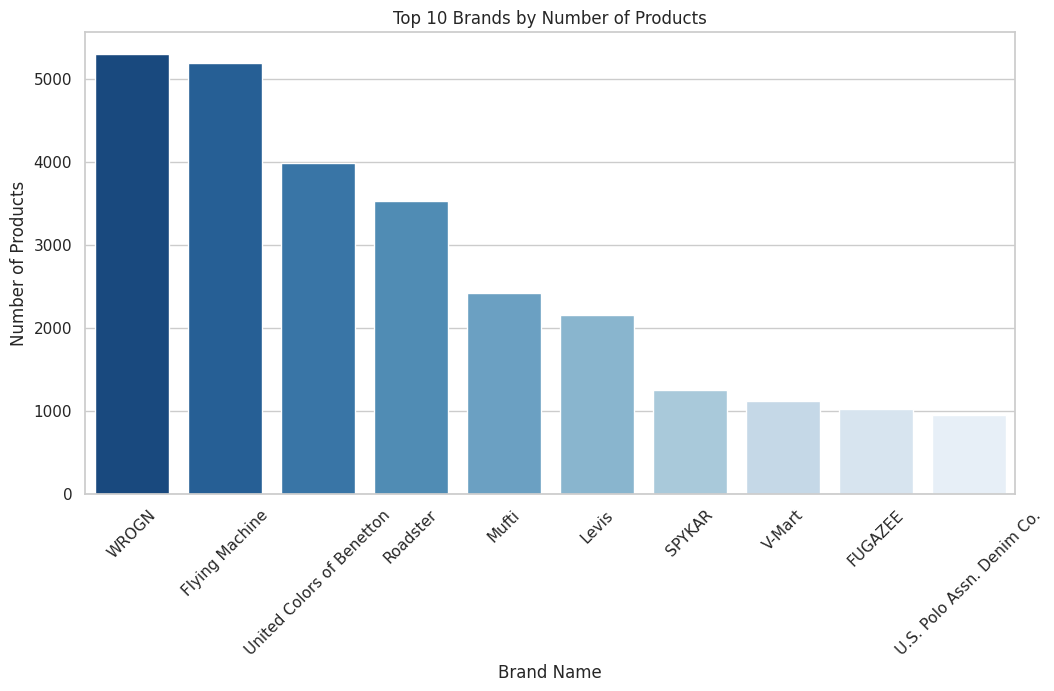

In [14]:
plt.figure(figsize=(12, 6))
top_brands = df['brand_name'].value_counts().head(10)
sns.barplot(x=top_brands.index, y=top_brands.values, palette="Blues_r")
plt.title("Top 10 Brands by Number of Products")
plt.xlabel("Brand Name")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

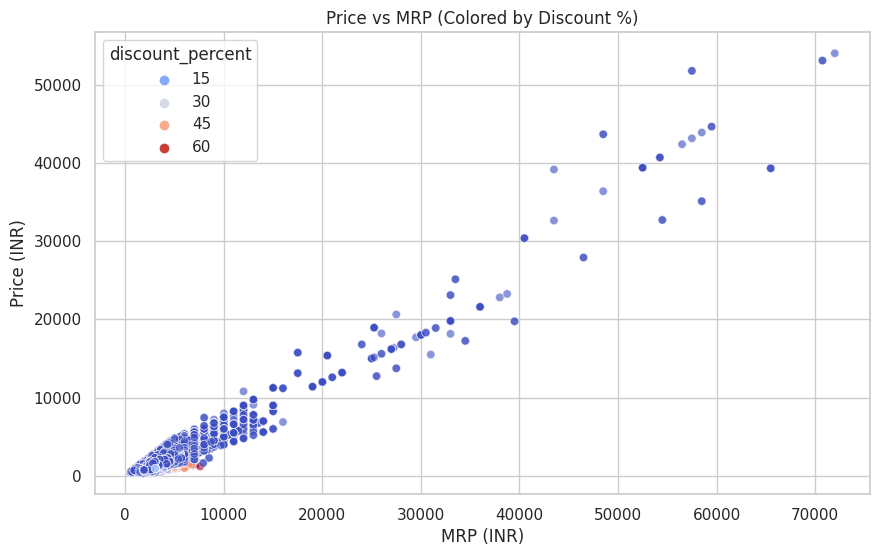

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['MRP'], y=df['price'], hue=df['discount_percent'], palette="coolwarm", alpha=0.6)
plt.title("Price vs MRP (Colored by Discount %)")
plt.xlabel("MRP (INR)")
plt.ylabel("Price (INR)")
plt.show()

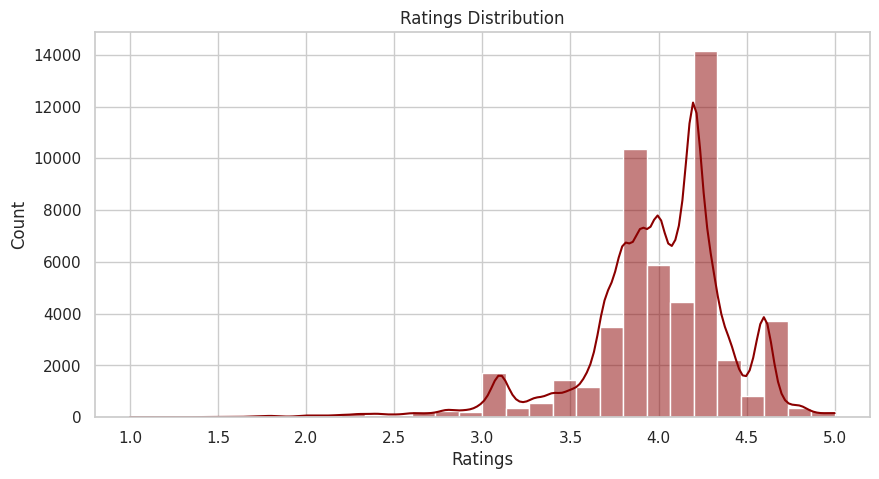

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df['ratings'], bins=30, kde=True, color="darkred")
plt.title("Ratings Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

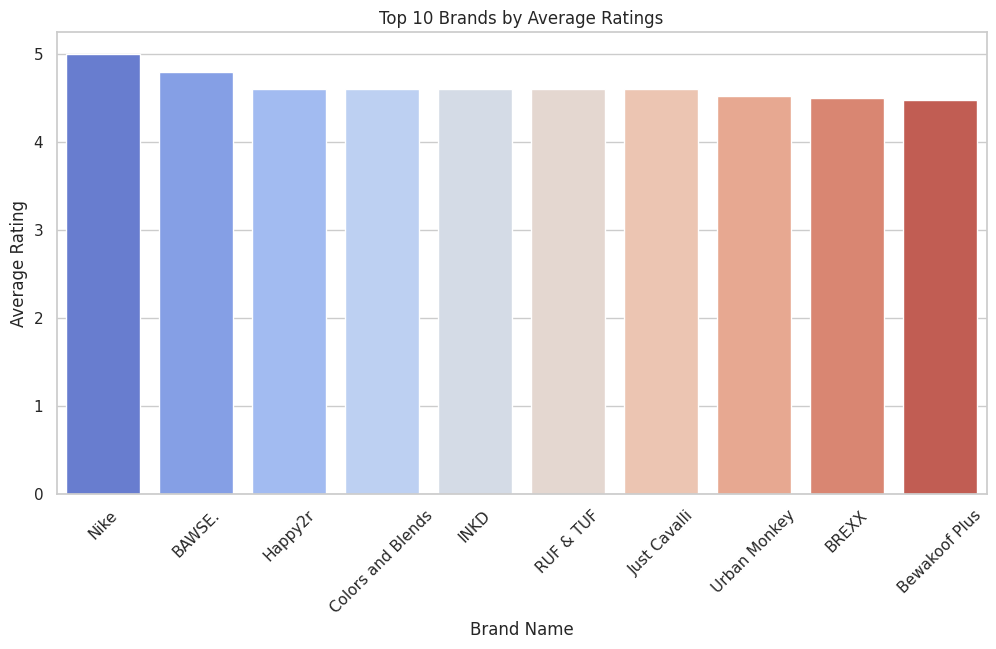

In [17]:
plt.figure(figsize=(12, 6))
avg_rating = df.groupby('brand_name')['ratings'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_rating.index, y=avg_rating.values, palette="coolwarm")
plt.title("Top 10 Brands by Average Ratings")
plt.xlabel("Brand Name")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

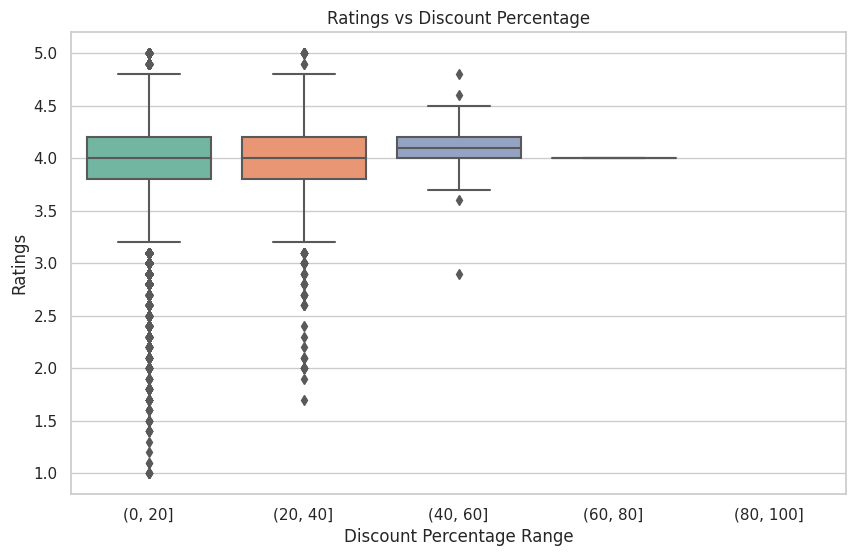

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=pd.cut(df['discount_percent'], bins=[0,20,40,60,80,100]), y=df['ratings'], palette="Set2")
plt.title("Ratings vs Discount Percentage")
plt.xlabel("Discount Percentage Range")
plt.ylabel("Ratings")
plt.show()

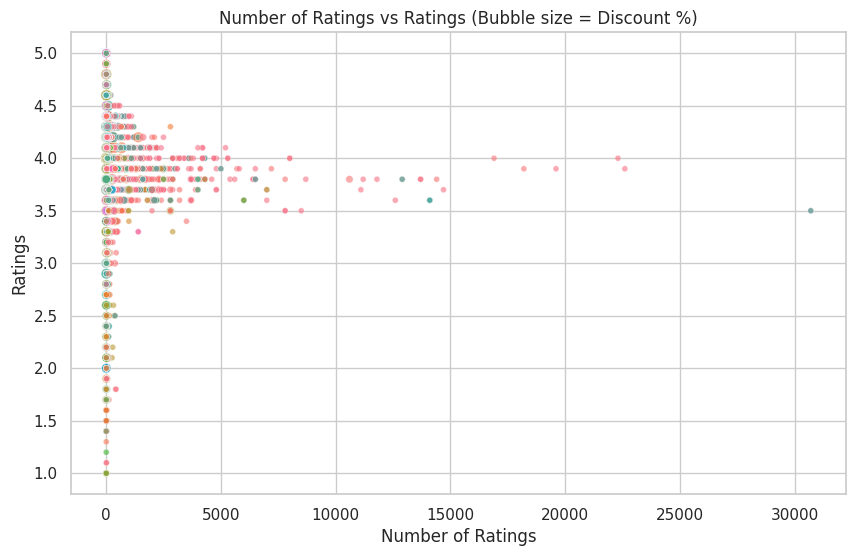

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="number_of_ratings", y="ratings",
                size="discount_percent", hue="brand_name", alpha=0.6, legend=False)
plt.title("Number of Ratings vs Ratings (Bubble size = Discount %)")
plt.xlabel("Number of Ratings")
plt.ylabel("Ratings")
plt.show()

## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [21]:
df = df.dropna()

# Create target variable: classify as Good (>=4) or Bad (<4)
df['rating_class'] = df['ratings'].apply(lambda x: 1 if x >= 4 else 0)

# Encode categorical columns
le_brand = LabelEncoder()
le_desc = LabelEncoder()
df['brand_name'] = le_brand.fit_transform(df['brand_name'])
df['pants_description'] = le_desc.fit_transform(df['pants_description'])

# Features and target
X = df[['brand_name', 'pants_description', 'price', 'MRP', 'discount_percent', 'number_of_ratings']]
y = df['rating_class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc

In [23]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy (%)"])
print(results_df)

                 Model  Accuracy (%)
0  Logistic Regression     59.871450
1        Decision Tree     80.372218
2        Random Forest     82.338833
3    Gradient Boosting     80.650422
4                  KNN     72.419417
5                  SVM     62.854950


## Thank you..pls upvote!!!